In [1]:
import kagglehub

path = kagglehub.dataset_download("shubham2703/five-crop-diseases-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/shubham2703/five-crop-diseases-dataset


In [3]:
import os
import shutil
import random

# 🔹 CORRECT path in Google Colab
input_dir = "/kaggle/input/datasets/shubham2703/five-crop-diseases-dataset/Crop Diseases Dataset/Crop Diseases/Crop___Disease"

# 🔹 Output directory (will be created in Colab working dir)
output_dir = "/content/crop_disease_dataset"

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

assert train_ratio + val_ratio + test_ratio == 1.0

# Create base folders
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)

# Loop through crops
for crop in os.listdir(input_dir):
    crop_path = os.path.join(input_dir, crop)

    if not os.path.isdir(crop_path):
        continue

    # Loop through diseases
    for disease in os.listdir(crop_path):
        disease_path = os.path.join(crop_path, disease)

        if not os.path.isdir(disease_path):
            continue

        images = [img for img in os.listdir(disease_path)
                  if os.path.isfile(os.path.join(disease_path, img))]

        random.shuffle(images)

        total = len(images)
        train_end = int(total * train_ratio)
        val_end = train_end + int(total * val_ratio)

        split_data = {
            "train": images[:train_end],
            "val": images[train_end:val_end],
            "test": images[val_end:]
        }

        for split, files in split_data.items():
            dest_folder = os.path.join(output_dir, split, crop, disease)
            os.makedirs(dest_folder, exist_ok=True)

            for file in files:
                src = os.path.join(disease_path, file)
                dst = os.path.join(dest_folder, file)

                shutil.copy2(src, dst)

print("✅ Dataset split completed!")

✅ Dataset split completed!


In [4]:
import os
import shutil

base_dir = "/content/crop_disease_dataset"

for split in ["train", "val", "test"]:
    split_path = os.path.join(base_dir, split)

    for crop in os.listdir(split_path):
        crop_path = os.path.join(split_path, crop)

        if not os.path.isdir(crop_path):
            continue

        for disease in os.listdir(crop_path):
            disease_path = os.path.join(crop_path, disease)

            if not os.path.isdir(disease_path):
                continue

            # New combined class name
            new_class_name = f"{crop}___{disease}"
            new_class_path = os.path.join(split_path, new_class_name)

            os.makedirs(new_class_path, exist_ok=True)

            # Move images
            for img in os.listdir(disease_path):
                src = os.path.join(disease_path, img)
                dst = os.path.join(new_class_path, img)

                shutil.move(src, dst)

        # Remove empty crop folder
        shutil.rmtree(crop_path)

print("✅ Dataset flattened successfully!")

✅ Dataset flattened successfully!


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import ImageFile

# 🔹 Allow loading truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

image_size = (224, 224) # Standard image size for many pre-trained models
batch_size = 32

# Data augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for validation and test data (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    '/content/crop_disease_dataset/train',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True # Shuffle training data
)

validation_generator = val_test_datagen.flow_from_directory(
    '/content/crop_disease_dataset/val',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # Do NOT shuffle validation data for consistent evaluation
)

test_generator = val_test_datagen.flow_from_directory(
    '/content/crop_disease_dataset/test',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # Do NOT shuffle test data for consistent evaluation
)

print("\nData generators created successfully!")
print(f"Number of training samples: {train_generator.samples}")
print(f"Number of validation samples: {validation_generator.samples}")
print(f"Number of test samples: {test_generator.samples}")
print(f"Classes: {train_generator.class_indices}")

2026-04-07 15:15:12.315068: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775574912.509590      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775574912.565987      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775574913.003865      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775574913.003907      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775574913.003910      55 computation_placer.cc:177] computation placer alr

Found 9322 images belonging to 17 classes.
Found 1992 images belonging to 17 classes.
Found 2010 images belonging to 17 classes.

Data generators created successfully!
Number of training samples: 9322
Number of validation samples: 1992
Number of test samples: 2010
Classes: {'Corn___Corn___Common_Rust': 0, 'Corn___Corn___Gray_Leaf_Spot': 1, 'Corn___Corn___Healthy': 2, 'Corn___Corn___Northern_Leaf_Blight': 3, 'Potato___Potato___Early_Blight': 4, 'Potato___Potato___Healthy': 5, 'Potato___Potato___Late_Blight': 6, 'Rice___Rice___Brown_Spot': 7, 'Rice___Rice___Healthy': 8, 'Rice___Rice___Leaf_Blast': 9, 'Rice___Rice___Neck_Blast': 10, 'Wheat___Wheat___Brown_Rust': 11, 'Wheat___Wheat___Healthy': 12, 'Wheat___Wheat___Yellow_Rust': 13, 'sugarcane___Bacterial Blight': 14, 'sugarcane___Healthy': 15, 'sugarcane___Red Rot': 16}


In [6]:
train_generator

In [7]:
for x,y in train_generator:
    print(x,x.shape)
    print(y,y.shape)
    break

[[[[0.2620421  0.2646154  0.21595484]
   [0.26294684 0.26371855 0.21627389]
   [0.26627472 0.26647785 0.22660773]
   ...
   [0.8352942  0.8352942  0.8308684 ]
   [0.8352942  0.8352942  0.8336049 ]
   [0.8363414  0.8363414  0.8363414 ]]

  [[0.26707777 0.2749209  0.22221394]
   [0.2606561  0.2658955  0.21621695]
   [0.2573808  0.263676   0.21456443]
   ...
   [0.83696043 0.83696043 0.83696043]
   [0.8396969  0.8396969  0.8396969 ]
   [0.8424334  0.8424334  0.8424334 ]]

  [[0.27012378 0.27796692 0.22664338]
   [0.2619222  0.2686099  0.21820724]
   [0.25824466 0.26399603 0.21406153]
   ...
   [0.8430524  0.8430524  0.8430524 ]
   [0.8431373  0.8404857  0.84181154]
   [0.8431373  0.83774924 0.84044325]]

  ...

  [[0.22375208 0.28660852 0.10212778]
   [0.22221684 0.28496194 0.1006482 ]
   [0.22084859 0.2835937  0.09927996]
   ...
   [0.81426513 0.8221083  0.8181867 ]
   [0.8078432  0.81568635 0.8117648 ]
   [0.8093346  0.8171777  0.81325614]]

  [[0.22053908 0.2832842  0.09897045]
   [0.2

In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Get the number of classes from the train_generator
num_classes = len(train_generator.class_indices)

# Load the VGG16 model with pre-trained ImageNet weights, excluding the top (classification) layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))

# Freeze the layers of the base model to prevent them from being updated during training
for layer in base_model.layers:
    layer.trainable = False

# Create a new model on top of the pre-trained base
model = Sequential()
model.add(base_model) # Add the pre-trained VGG16 base

# Add custom classification layers
model.add(GlobalAveragePooling2D()) # Use GlobalAveragePooling2D instead of Flatten for better performance and reduced overfitting
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax')) # Output layer with number of classes and softmax activation

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001), # Lower learning rate for fine-tuning pre-trained models
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1775574965.207478      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,385 (56.65 MB)

 Trainable params: 135,697 (530.07 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
training_history = model.fit(x=train_generator,validation_data=validation_generator,epochs=40,verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


I0000 00:00:1775574988.758837     148 service.cc:152] XLA service 0x7c493c00dca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775574988.758883     148 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775574989.271433     148 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/292 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - accuracy: 0.0391 - loss: 3.0057 

I0000 00:00:1775574997.702313     148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


292/292 ━━━━━━━━━━━━━━━━━━━━ 222s 724ms/step - accuracy: 0.1672 - loss: 2.6521 - val_accuracy: 0.5617 - val_loss: 1.8946
Epoch 2/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 207s 710ms/step - accuracy: 0.4623 - loss: 1.9024 - val_accuracy: 0.6727 - val_loss: 1.4444
Epoch 3/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 204s 701ms/step - accuracy: 0.5819 - loss: 1.5120 - val_accuracy: 0.6913 - val_loss: 1.1854
Epoch 4/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 205s 702ms/step - accuracy: 0.6164 - loss: 1.3041 - val_accuracy: 0.7068 - val_loss: 1.0265
Epoch 5/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 200s 686ms/step - accuracy: 0.6516 - loss: 1.1543 - val_accuracy: 0.7244 - val_loss: 0.9179
Epoch 6/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 212s 725ms/step - accuracy: 0.6755 - loss: 1.0394 - val_accuracy: 0.7334 - val_loss: 0.8442
Epoch 7/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 209s 717ms/step - accuracy: 0.6746 - loss: 0.9854 - val_accuracy: 0.7395 - val_loss: 0.7820
Epoch 8/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 205s 701ms/step - accuracy: 0.6953 - loss: 0.91

Model saved successfully as 'crop_disease_model2.h5'

Final Training Accuracy: 0.8004
Final Validation Accuracy: 0.8288


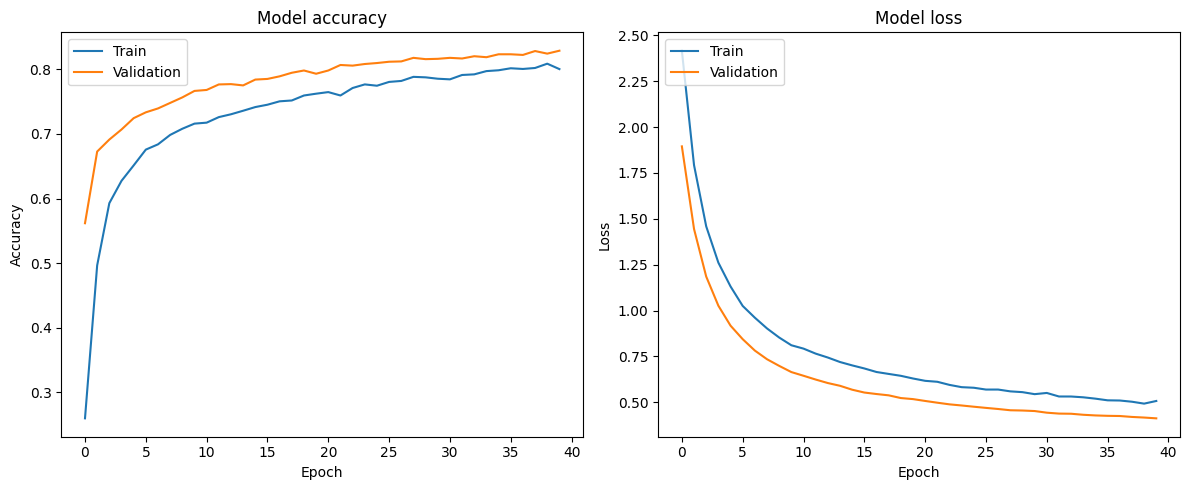

In [12]:
import matplotlib.pyplot as plt

# 1. Save the model
model.save('crop_disease_model2.h5')
print("Model saved successfully as 'crop_disease_model2.h5'")

# 2. Print accuracy
print(f"\nFinal Training Accuracy: {training_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {training_history.history['val_accuracy'][-1]:.4f}")

# 3. Visualize accuracy
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(training_history.history['accuracy'])
plt.plot(training_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(training_history.history['loss'])
plt.plot(training_history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 345ms/step

Classification Report:
                                    precision    recall  f1-score   support

         Corn___Corn___Common_Rust     0.9572    0.9944    0.9755       180
      Corn___Corn___Gray_Leaf_Spot     0.8333    0.6410    0.7246        78
             Corn___Corn___Healthy     0.9053    0.9829    0.9425       175
Corn___Corn___Northern_Leaf_Blight     0.8280    0.8725    0.8497       149
    Potato___Potato___Early_Blight     0.9592    0.9400    0.9495       150
         Potato___Potato___Healthy     1.0000    0.2083    0.3448        24
     Potato___Potato___Late_Blight     0.8382    0.9667    0.8978       150
          Rice___Rice___Brown_Spot     0.6667    0.1935    0.3000        93
             Rice___Rice___Healthy     0.6262    0.8973    0.7376       224
          Rice___Rice___Leaf_Blast     0.6068    0.4797    0.5358       148
          Rice___Rice___Neck_Blast     0.9932    0.9800    0.9866       150
        Wheat___Wheat

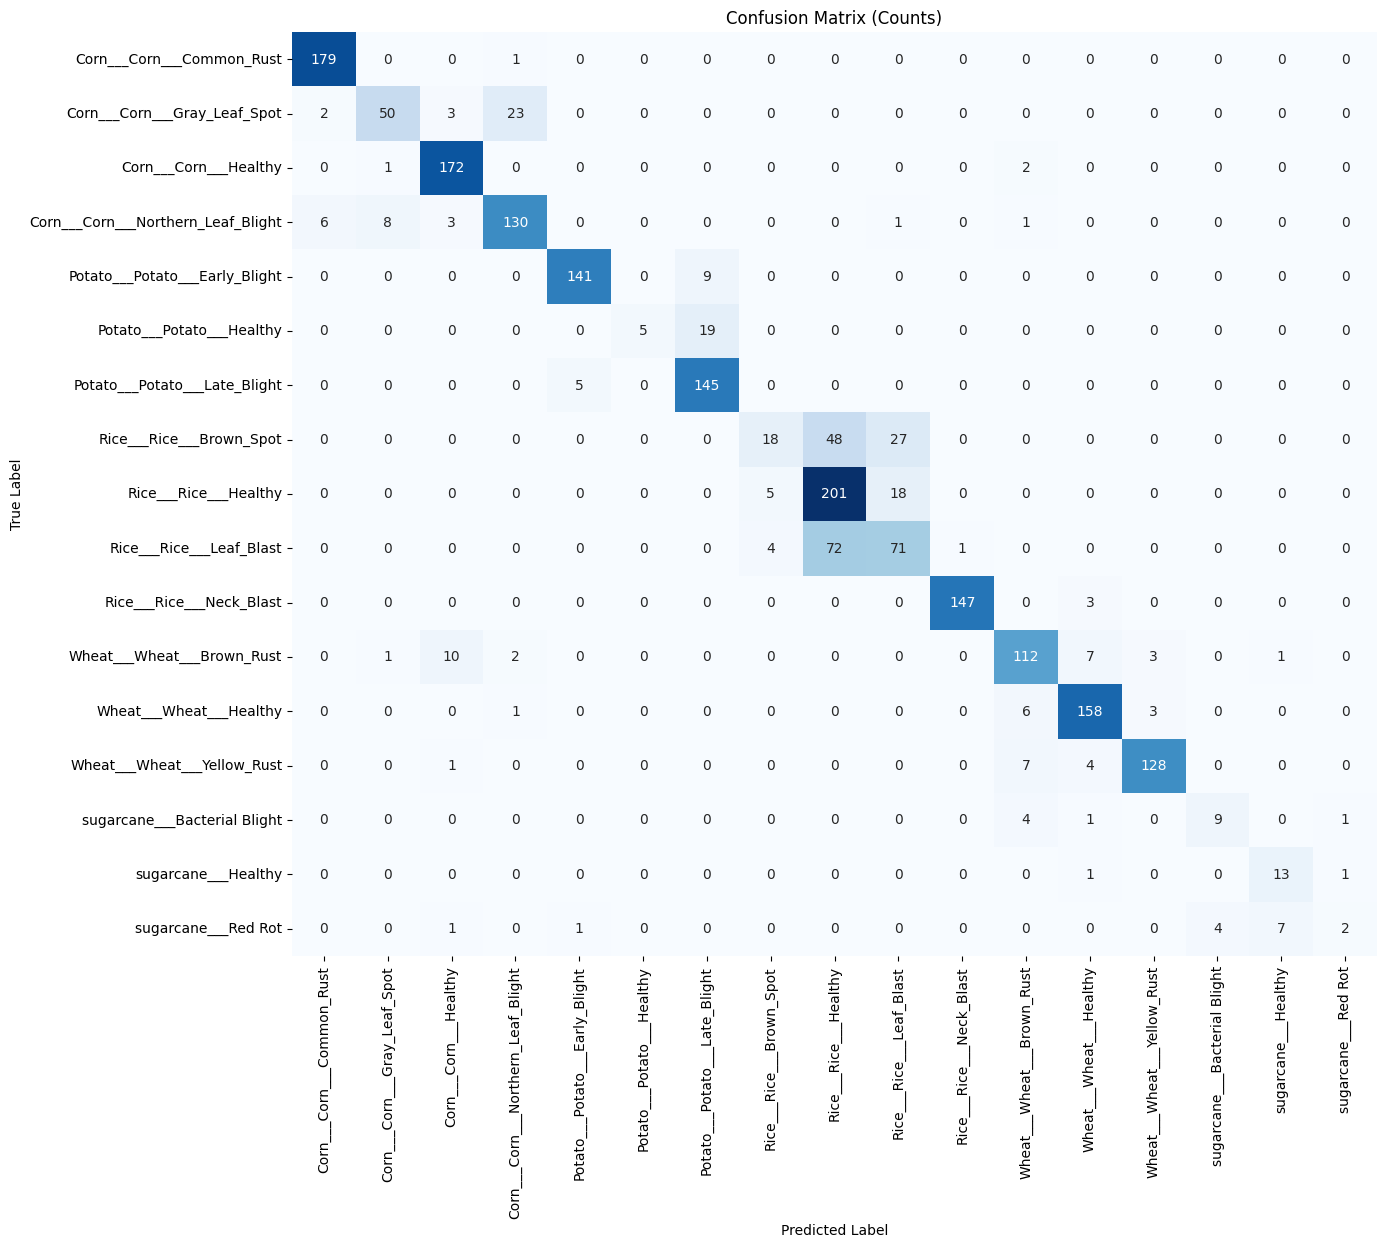

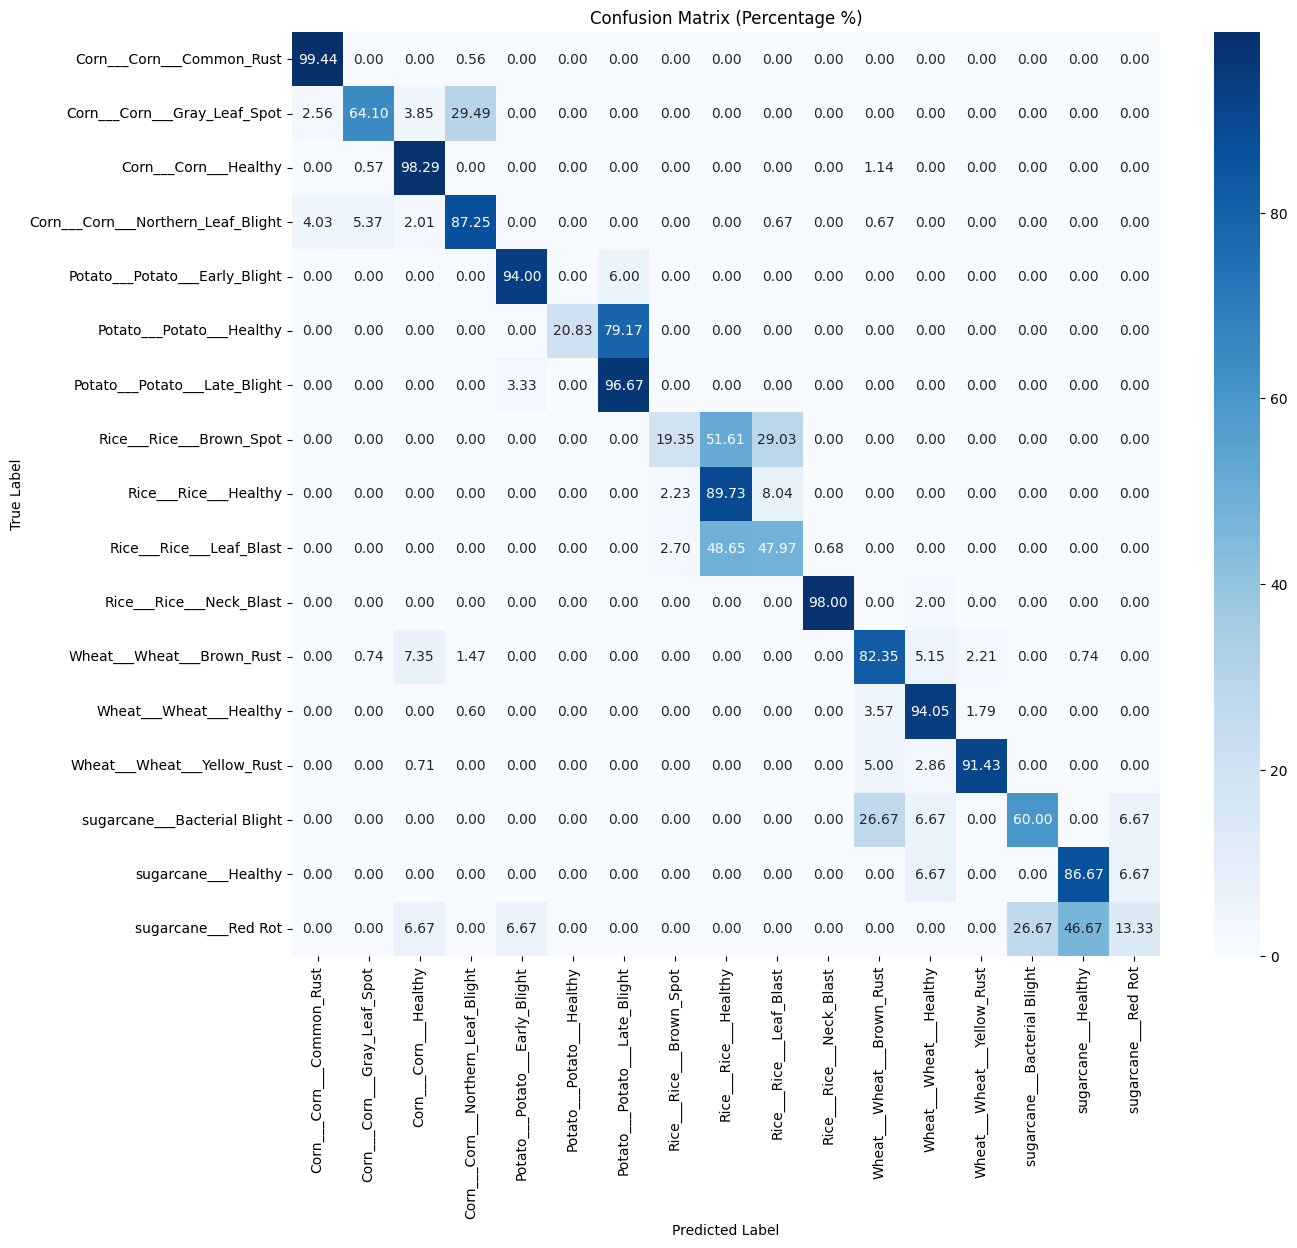

In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# -----------------------------
# Predict on the test data
# -----------------------------
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # convert to %

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=False)
plt.title('Confusion Matrix (Counts)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Confusion Matrix as Percentages
plt.figure(figsize=(14, 12))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.title('Confusion Matrix (Percentage %)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()